Proyecto: Predicción de ventas según la inversión en canales publicitarios (TV, Radio y Newspaper).

En este proyecto vamos a predecir las ventas según el valor invertido en X medios, dígase: TV, Periodico y la Radio.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt


2- Carga de datos

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/predict sales /advertising.csv')

3- EDA

In [ ]:
# Visualización breve del dataset

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
# Dimensión

df.shape

(200, 4)

In [ ]:
# Nulos y tipo de dato

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
# Estadísticas generales

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


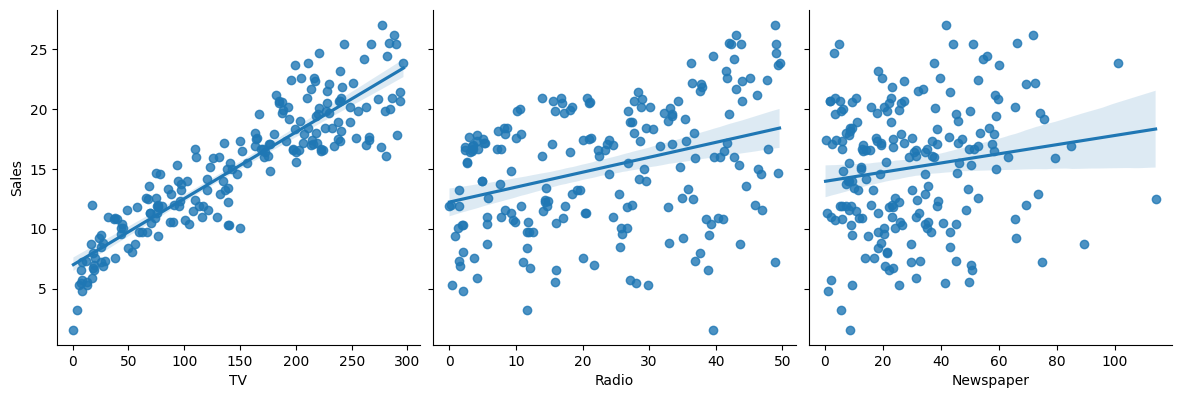

In [ ]:
# Gráfico de pares

# A simple vista detectamos que TV es donde más impacto tiene en las ventas según lo que se invierte, es decir, mientras mas se invierte en el medio, más ventas genera...
# con radio no se visualiza eso, se detecta que no hay mucha correlación con las ventas y la inversión en ese medio, pero hay un ligera correlación.
# con Newspaper vemos una correlación muy debil con las ventas y su inversión.

sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.show()

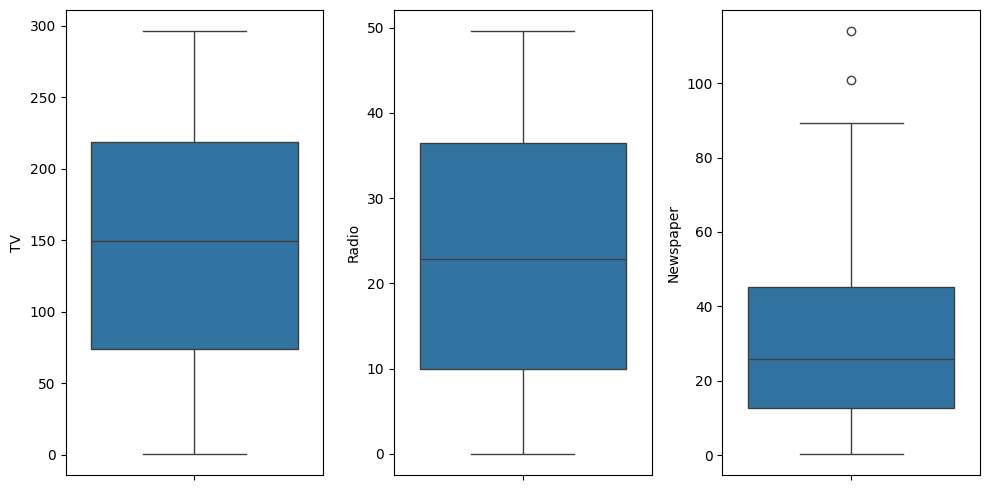

In [ ]:
# Boxplots

fig, axes = plt.subplots(1,3,figsize=(10,5))

sns.boxplot(df['TV'], ax=axes[0])
sns.boxplot(df['Radio'], ax=axes[1])
sns.boxplot(df['Newspaper'], ax=axes[2])
plt.tight_layout()

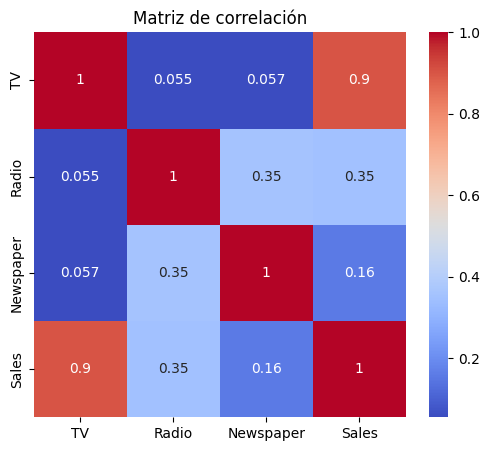

In [ ]:
# Matriz de correlación

# Aqui visualizamos que 'TV' es la variable que más correlación tiene con las ventas, en cambio Radio ligeramente correlacionada y Newspaper muy debil correlación.
# esto nos da un primer vistazo de que TV es el la variable que impulsa más a las ventas.

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

3- División de las variables (independientes y dependiente)

In [ ]:
X = df.drop(columns='Sales',axis='columns')
y = df['Sales']

In [ ]:
print(f'Dimensión X: {X.shape} ')
print(f'Dimensión y: {y.shape}')

Dimensión X: (200, 3) 
Dimensión y: (200,)


4- División de datos de entrenamiento (80) y prueba (20)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 3), (40, 3), (160,), (40,))

5- Escalado de variables

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Los pasamos a DataFrame:

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)


In [ ]:
X_train_scaled.head()

,TV,Radio,Newspaper
79,-0.404248,-1.028237,-0.337675
197,0.320608,-0.919828,-1.161439
38,-1.270511,0.259124,0.254251
24,-1.042359,-0.696233,-0.574446
122,0.879103,-1.387343,-0.707629


6- Entrenamiento del modelo (con escalado y sin escalado)

In [ ]:
from sklearn.linear_model import LinearRegression

# Modelo 1: sin escalar

modelo_original = LinearRegression()
modelo_original.fit(X_train, y_train)

# Modelo 2: escalado

modelo_escalado = LinearRegression()
modelo_escalado.fit(X_train_scaled, y_train)

print("=== Modelo SIN escalar ===")
print("Intercepto:", modelo_original.intercept_)
for col, coef in zip(X.columns, modelo_original.coef_):
    print(f"{col}: {coef:.4f}")

print("\n=== Modelo ESCALADO ===")
print("Intercepto:", modelo_escalado.intercept_)
for col, coef in zip(X.columns, modelo_escalado.coef_):
    print(f"{col}: {coef:.4f}")

=== Modelo SIN escalar ===
Intercepto: 4.714126402214127
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043

=== Modelo ESCALADO ===
Intercepto: 15.330625000000003
TV: 4.5872
Radio: 1.4898
Newspaper: 0.0879


7- Test de semajanza de modelo sin escalar y escalado

In [ ]:
pred_original = modelo_original.predict(X_test)
pred_escalado = modelo_escalado.predict(X_test_scaled)

print(f'Predicciones semejantes?:', np.allclose(pred_original, pred_escalado))

Predicciones semejantes?: True


8- Evaluación de métricas en el conjunto de prueba

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo_original.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print('-'*70)

# Comparar contra el rendimiento en TRAIN, para detectar overfitting

y_pred_train = modelo_original.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"R² en TRAIN: {r2_train:.4f}")
print(f"R² en TEST:  {r2:.4f}")

MAE:  1.2748
RMSE: 1.7052
R²:   0.9059
----------------------------------------------------------------------
R² en TRAIN: 0.9001
R² en TEST:  0.9059


 Teniendo en cuenta que el RMSE (1.7052) es más alto que el MAE (1.2748),
 esto sugiere la presencia de algunos errores puntuales más grandes que el promedio.
 Visualizamos los residuos y confirmamos: no hay un patrón sistemático (no hay forma
 de embudo ni de U), solo ruido disperso más un caso outlier (~-5.3) que explica
 la diferencia entre RMSE y MAE. En términos relativos, un RMSE de 1.7 sobre un
 rango de Sales de ~1 a 27 representa un error típico de ~6.5% del rango total,
 lo cual es un desempeño sólido para datos de comportamiento de mercado.

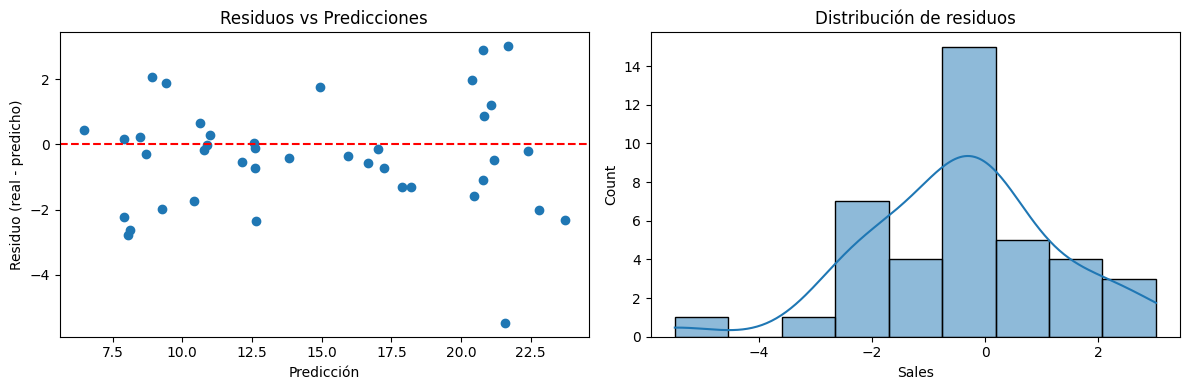

In [ ]:


residuos = y_test - y_pred
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y_pred, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residuo (real - predicho)')
plt.title('Residuos vs Predicciones')

plt.subplot(1,2,2)
sns.histplot(residuos, kde=True)
plt.title('Distribución de residuos')

plt.tight_layout()
plt.show()

In [ ]:
# Identificación del mayor error de residuo

idx_peor = residuos.abs().idxmax() # abs() pone todos los valores en + positivos, idxmax() te devuelve el indice y el valor más alto de cada fila
print(df.loc[idx_peor])
print(f'Real: {y_test.loc[idx_peor]}, Predicho: {y_pred[y_test.index.get_loc(idx_peor)]:.2f}')

TV           280.7
Radio         13.9
Newspaper     37.0
Sales         16.1
Name: 150, dtype: float64
Real: 16.1, Predicho: 21.58


9- Predicciones con datos nuevos

In [ ]:
# nueva_inversion = pd.DataFrame({'TV': [150], 'Radio':[25], 'Newspaper':[5]})
# prediccion = modelo_original.predict(nueva_inversion)
# print(f'Ventas predichas: {prediccion[0]:.2f} (en miles de unidades)' )

# ------------------------------------------------------------------------------------------------------------------

# Funciones para para predecir las ventas según su inversión en cada medio.

def prediccion(TV, Radio, Newspaper):
  inversion = pd.DataFrame({'TV': [TV], 'Radio': [Radio], 'Newspaper': [Newspaper]})
  prediccion_inversion = modelo_original.predict(inversion)
  return prediccion_inversion[0]

def solicitar_inversion():
    print('Predicción de ventas según inversión publicitaria')

    while True:
        try:
            tv = float(input('Inversión en TV (miles de $): '))
            radio = float(input('Inversión en radio (miles de $): '))
            newspaper = float(input('Inversión en Newspaper (miles de $): '))

            if tv < 0 or radio < 0 or newspaper < 0:
                print('Error. Las inversiones no pueden ser negativas.')
                continue

            # Predicción
            ventas = prediccion(tv, radio, newspaper)
            print(f'Ventas predichas: {ventas:.2f} (miles de unidades)')

            # Advertencia si se exceden los rangos del dataset
            if tv > df['TV'].max() or radio > df['Radio'].max() or newspaper > df['Newspaper'].max():
                print("Nota: al menos un valor ingresado está fuera del rango observado en los datos de entrenamiento.")
                print("El modelo está extrapolando — la predicción es menos confiable.")

            break

        except ValueError:
            print("Error.Ingresa solo números (usa punto decimal, no coma). Intenta de nuevo.\n")

solicitar_inversion()


Predicción de ventas según inversión publicitaria


En conclusión, hemos detectado que la variable independiente que más influye en las ventas es el medio publicitario TV, en cambio Radio tiene un impulso/correlación moderado a las ventas, y Newspaper prácticamente nada. Se recomienda de manera principal invertir siempre en TV más que en otro medio publicitario.

El modelo de regresión lineal obtuvo un R² de aproximadamente 0.90 tanto en entrenamiento (0.9001) como en test (0.9059), sin señales de overfitting, y un MAE de 1.27 en el conjunto de test. Esto indica que el modelo explica la gran mayoría de la variabilidad de las ventas con un error de predicción bajo.